In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

import sys
sys.path.append("C:/Users/siddh/Desktop/Graduate Files/Research/mpemba_functions")
import mpemba
import fokker_planck

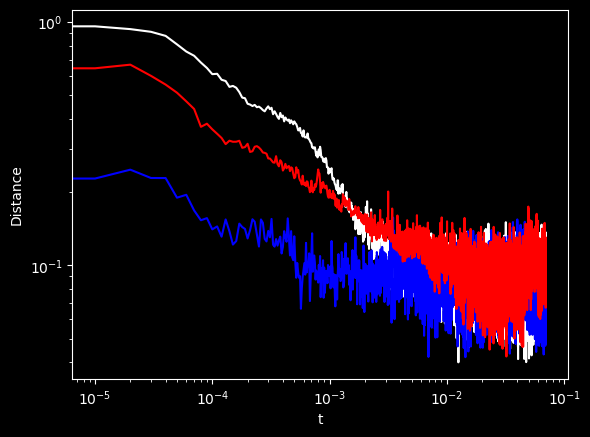

In [16]:
filename = "data.txt"

data = mpemba.file_processing.extract_file_data(filename, cols_to_extract=['x','drift','x0'])
potential = mpemba.special_potentials.AsymmetricDoubleWellPotential(E_tilt=0.6, force_asymmetry=0.3)

ensemble = mpemba.Ensemble(data.x, potential)
ensemble.plot_distances(colors=['r','b','w'])

In [17]:
ensemble.data

<xarray.DataArray 'x' (T: 3, n: 1358, t: 7000)>
array([[[ 0.197034,  0.139087,  0.18054 , ..., -0.025034, -0.026088,
         -0.100389],
        [-0.40837 , -0.417511, -0.465119, ...,  0.367647,  0.343913,
          0.345093],
        [ 0.020685, -0.011031,  0.016058, ..., -0.142599, -0.107324,
         -0.119926],
        ...,
        [-0.752988, -0.738464, -0.725129, ...,  0.080434,  0.052603,
          0.070184],
        [-0.123614, -0.16613 , -0.204613, ..., -0.372598, -0.334789,
         -0.27037 ],
        [ 0.430953,  0.425473,  0.464914, ...,  0.588887,  0.609841,
          0.656635]],

       [[-0.380189, -0.422932, -0.399616, ...,  0.260284,  0.244744,
          0.2017  ],
        [ 0.293989,  0.306734,  0.322392, ...,  0.470762,  0.516056,
          0.520831],
        [ 0.471155,  0.494075,  0.459625, ..., -0.377774, -0.48591 ,
         -0.415118],
...
        [ 0.26199 ,  0.338852,  0.287634, ...,  0.376936,  0.348033,
          0.379839],
        [ 0.044705,  0.035401,  0.04097 , ...,  0.328694,  0.344567,
          0.388565],
        [-0.308   , -0.268819, -0.286746, ...,  0.384966,  0.442373,
          0.394918]],

       [[ 0.118982,  0.117427,  0.139508, ...,  0.276818,  0.204632,
          0.208318],
        [-0.31485 , -0.277361, -0.232117, ...,  0.421367,  0.409967,
          0.393391],
        [ 0.952703,  0.993314,  1.02    , ..., -0.44964 , -0.431208,
         -0.405066],
        ...,
        [ 0.873991,  0.830623,  0.76311 , ..., -0.416575, -0.441467,
         -0.410128],
        [ 1.612316,  1.58461 ,  1.575408, ...,  0.340523,  0.377583,
          0.322431],
        [-0.155847, -0.128017, -0.115913, ...,  0.556145,  0.509426,
          0.500803]]])
Coordinates:
  * t        (t) float64 0.0 1e-05 2e-05 3e-05 ... 0.06997 0.06998 0.06999
  * T        (T) int32 12 3 1
Dimensions without coordinates: n

(array([0.07323892, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.03661946, 0.        , 0.        , 0.21971675,
        0.36619458, 0.62253079, 0.98872537, 1.17182267, 1.72111454,
        1.09858375, 1.57463671, 1.57463671, 0.95210592, 0.84224754,
        0.91548646, 0.98872537, 0.84224754, 0.878867  , 1.57463671,
        2.23378696, 3.44222908, 3.33237071, 3.18589287, 3.66194583,
        5.05348525, 4.10137933, 4.24785716, 2.56336208, 0.84224754,
        0.51267242, 0.07323892, 0.        , 0.        , 0.03661946]),
 array([-0.294946 , -0.2748371, -0.2547282, -0.2346193, -0.2145104,
        -0.1944015, -0.1742926, -0.1541837, -0.1340748, -0.1139659,
        -0.093857 , -0.0737481, -0.0536392, -0.0335303, -0.0134214,
         0.0066875,  0.0267964,  0.0469053,  0.0670142,  0.0871231,
         0.107232 ,  0.1273409,  0.1474498,  0.1675587,  0.1876676,
         0.2077765,  0.2278854,  0.2479943,  0.2681032,  0.2882121,
         0.308321 ,  0.3284299,  0.3485388,  0

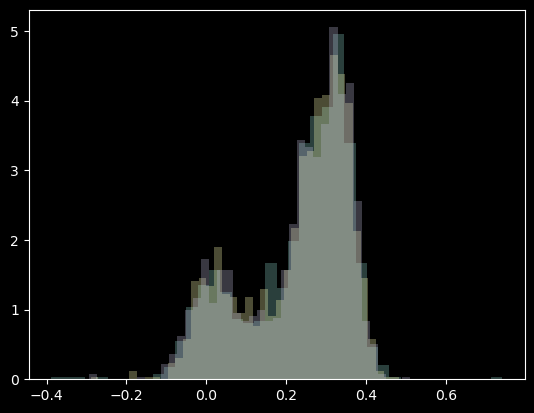

In [4]:
drift = data.drift[:,:,0].to_numpy()
plt.hist(drift[0,:], bins=40, alpha=0.3, density=True)
plt.hist(drift[1,:], bins=40, alpha=0.3, density=True)
plt.hist(drift[2,:], bins=40, alpha=0.3, density=True)

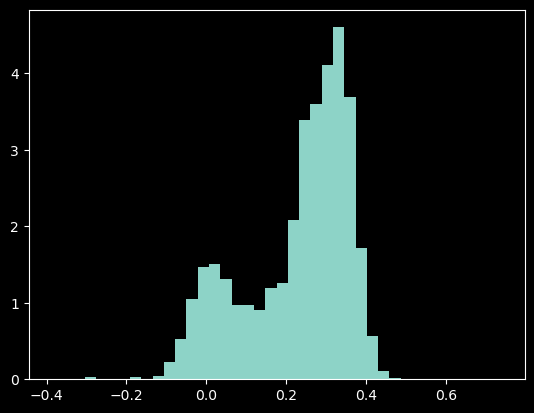

In [5]:
heights, bins, _ = plt.hist(drift.flatten(), bins=40, density=True)

In [6]:
drift.flatten('F')

array([0.205806, 0.154008, 0.200449, ..., 0.349131, 0.411548, 0.330017])

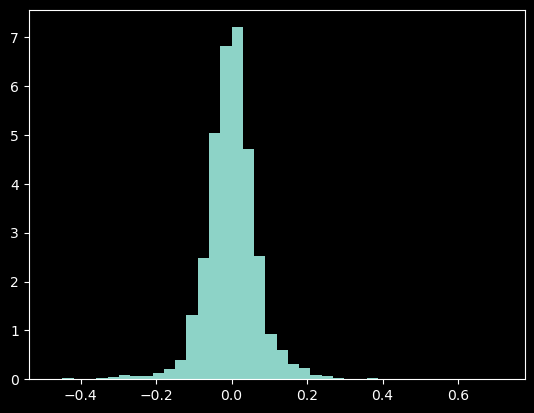

In [7]:
drift_vel = np.diff(drift.flatten('F'))
drift_vel_heights, drift_vel_bins, _ = plt.hist(drift_vel, bins=40, density=True)

In [8]:
drift_vel.mean(), drift_vel.std()

(3.049619445126449e-05, 0.0717631530603575)

In [9]:
bins1 = bins[:-1]-(bins[1]-bins[0])/2
df = pd.DataFrame(heights, index=bins1, columns=['drift'])
df.index.name='x'
df.to_csv("drifts.csv")
bins2 = drift_vel_bins[:-1]-(drift_vel_bins[1]-drift_vel_bins[0])/2
df2 = pd.DataFrame(drift_vel_heights, index=bins2, columns=['driftvel'])
df2.index.name='v'
df2.to_csv('driftvel.csv')

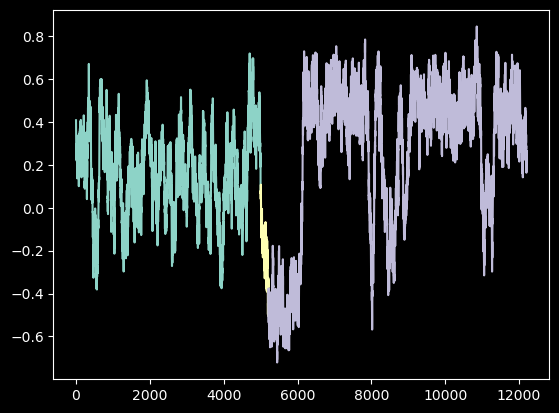

In [18]:
calibration, positioning, protocol = mpemba.file_processing.get_states_of_single_trajectory("data.txt", T=1)

positioning['x0'] = positioning.x + calibration.x.mean()
protocol['x0'] = protocol.x + calibration.x.mean()
for df in [calibration, positioning, protocol]:
    df['t'] = df['t']*1e-5

plt.plot(calibration.x)
plt.plot(positioning.x)
plt.plot(protocol.x)

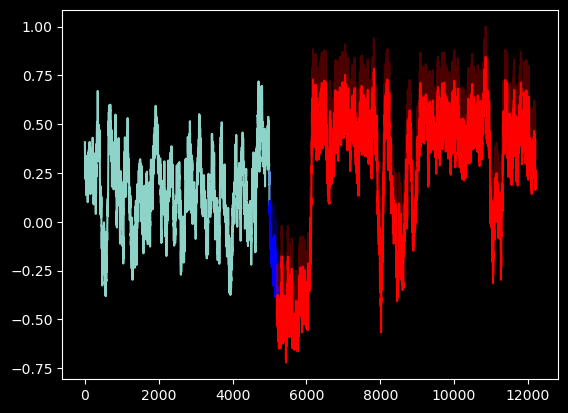

In [19]:
plt.plot(calibration.x)
plt.plot(positioning.x, color='b', alpha=1)
plt.plot(positioning.x+calibration.x.mean(), color='b', alpha=0.3)
plt.plot(protocol.x, color='r', alpha=1)
plt.plot(protocol.x+calibration.x.mean(), color='r', alpha=0.3)

In [20]:
calibration.mean(), calibration.t

(x    0.155966
 t    0.025005
 T    1.000000
 dtype: float64,
 0       0.00001
 1       0.00002
 2       0.00003
 3       0.00004
 4       0.00005
          ...   
 4995    0.04996
 4996    0.04997
 4997    0.04998
 4998    0.04999
 4999    0.05000
 Name: t, Length: 5000, dtype: float64)

In [35]:
calibration.to_csv("calibration_trajectory.csv", index=None)
protocol.to_csv("protocol_trajectory.csv", index=None)
positioning.to_csv("positioning_trajectory.csv", index=None)

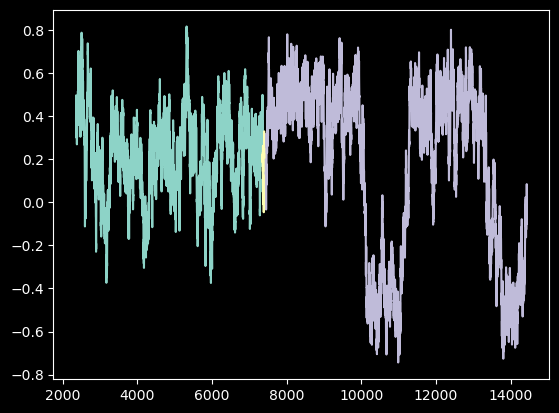

In [13]:
calibration2, positioning2, protocol2 = mpemba.file_processing.get_states_of_single_trajectory("data.txt", T=2)

positioning2['x0'] = positioning2.x + calibration2.x.mean()
protocol2['x0'] = protocol2.x + calibration2.x.mean()

for df in [calibration2, positioning2, protocol2]:
    df['t'] = df['t']*1e-5

plt.plot(calibration2.x)
plt.plot(positioning2.x)
plt.plot(protocol2.x)

In [14]:
calibration2.mean()

x    0.210769
t    0.025005
T    2.000000
dtype: float64

In [41]:
calibration2.to_csv("calibration_trajectory_2.csv", index=None)
protocol2.to_csv("protocol_trajectory_2.csv", index=None)
positioning2.to_csv("positioning_trajectory_2.csv", index=None)

In [21]:
drift_series = data.drift[:,:,0].to_numpy().flatten(order='F')
with open("data.txt", "rb") as f:
    total_time = sum(1 for _ in f)*1e-5

average_protocol_time = total_time/(data.x.shape[1]*data.x.shape[0])

In [25]:
np.std([84,84,84.6])

0.2828427124746163

In [22]:
average_protocol_time

0.12272950417280315

(0.016151394505278704,
 38.00720112382654,
 0.37144104835533825,
 7.993850067509582)

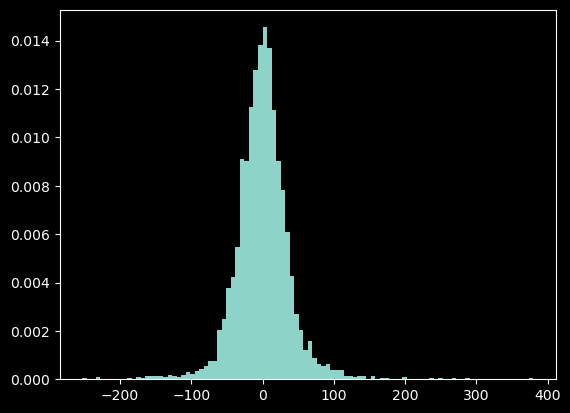

In [23]:
px_to_nm = 65
drift_velocities = px_to_nm*np.diff(drift_series)/average_protocol_time
plt.hist(drift_velocities, bins=100, density=True)
drift_velocities.mean(), drift_velocities.std(), scipy.stats.skew(drift_velocities), scipy.stats.kurtosis(drift_velocities)
# mesh = potential.mesh(500)
# plt.plot(mesh, (potential.boltzmann(mesh, 1)+ potential.boltzmann(mesh,3)+potential.boltzmann(mesh, 12))/3)

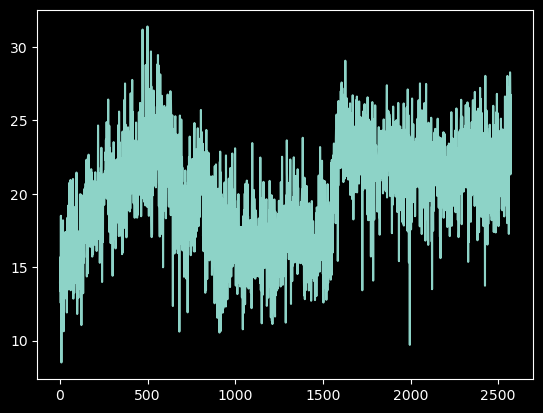

In [24]:
plt.plot(px_to_nm*drift_series[1500:])
df = pd.DataFrame(np.array([px_to_nm*drift_series[1500:-1], drift_velocities[1500:]]).T, columns=['drift', 'driftvel'], index=np.arange(drift_series[1500:-1].size)*average_protocol_time)
df.index.name = 't'
df.to_csv("drift_series.csv")

,p
-246.876484,0.000019
-234.220579,0.000039
-221.564673,0.000000
-208.908768,0.000000
-196.252862,0.000000
-183.596957,0.000019
-170.941052,0.000058
-158.285146,0.000136
-145.629241,0.000136
-132.973335,0.000136


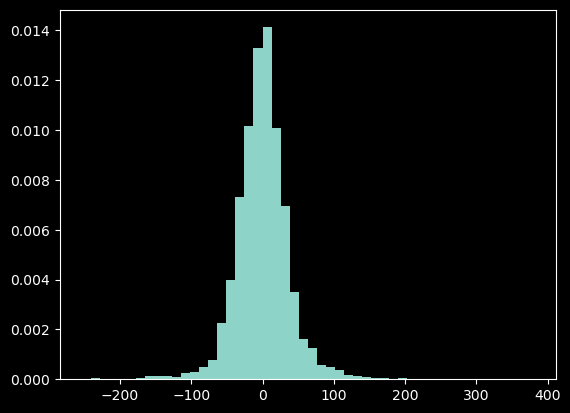

In [ ]:
# heights, bins, _ = plt.hist(drift_velocities, bins=50, density=True)
# df = pd.DataFrame(heights, columns=['p'], index=bins[1:]-(bins[1]-bins[0])/2)
# df.to_csv("d")